# 2 · Train a six-hour forecast: configuration as an experiment

**Question:** what changes when the same small forecasting recipe receives **16 versus 32 optimizer updates**?
You will predict effective settings, inspect Hydra composition, diagnose a typo, run two real Anemoi jobs, and interpret their loss and checkpoint evidence.

This is an intermediate workflow exercise, not a forecast-skill benchmark. The data subset, short runs and one seed cannot establish climate or operational forecast skill. Run both trials on a machine with a CUDA GPU.

**Handoff:** notebook 1 supplied the K=4 graph at `graphs/o48-o32.pt`. We retain the 16-update checkpoint as the primary input to notebook 3 and record the 32-update checkpoint separately.

> **Before you start**
>
> - **Environment:** from the repository root run `uv sync --group module-03-04`, start JupyterLab with `uv run jupyter lab`, and open this notebook with the `python3` kernel.
> - **Data:** `data/module-03_04/` must contain `era5-o48-2020-2021-6h-v0.zarr` and `grids/grid-o32.npz`. Download the course record ([doi:10.5281/zenodo.23099483](https://doi.org/10.5281/zenodo.23099483)) and run `unzip course-module-03_04.zip` from the repository root.
> - **Outputs:** everything the notebooks create is written to `output/module-03_04/`.
> - **Hardware:** a CUDA GPU (driver supporting CUDA 12.8 or newer) is required.
> - **Order:** needs `graphs/o48-o32.pt` from Notebook 1; it writes the checkpoints and `training-result-6h.json` that Notebook 3 reads.

In [1]:
import os
import sys
from pathlib import Path

# Work from the repository root (the folder with pyproject.toml), whatever directory JupyterLab was started from
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(root)

# Inputs, outputs and configs of Modules 3-4 (the two environment variables can override the defaults)
DATA = Path(os.environ.get("ANEMOI_COURSE_DATA", "data/module-03_04")).resolve()
OUTPUT = Path(os.environ.get("ANEMOI_COURSE_OUTPUT", "output/module-03_04")).resolve()
DATASET = DATA / "era5-o48-2020-2021-6h-v0.zarr"
CONFIG_DIR = Path("configs/module-03_04")

# The Hydra configs and the %%bash cells read the two paths from environment variables
os.environ["ANEMOI_COURSE_DATA"] = str(DATA)
os.environ["ANEMOI_COURSE_OUTPUT"] = str(OUTPUT)
# Run the anemoi-* commands of this environment
os.environ["PATH"] = f"{Path(sys.executable).parent}{os.pathsep}{os.environ['PATH']}"

sys.path.insert(0, "notebooks/module-03_04")
from course import check_environment

check_environment(DATASET, DATA / "grids/grid-o32.npz", OUTPUT, gpu=True)

{
  "data": "/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets",
  "output": "/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312",
  "versions": {
    "anemoi-datasets": "0.5.36",
    "anemoi-graphs": "0.9.3",
    "anemoi-inference": "0.10.1",
    "anemoi-models": "0.14.1",
    "anemoi-training": "0.12.1",
    "anemoi-transform": "0.3.1",
    "anemoi-utils": "0.5.3"
  },
  "job_id": "46536603",
  "gpu": "NVIDIA H100",
  "capacity_gib": 63.29
}


{'data': '/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets',
 'output': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312',
 'versions': {'anemoi-datasets': '0.5.36',
  'anemoi-graphs': '0.9.3',
  'anemoi-inference': '0.10.1',
  'anemoi-models': '0.14.1',
  'anemoi-training': '0.12.1',
  'anemoi-transform': '0.3.1',
  'anemoi-utils': '0.5.3'},
 'job_id': '46536603',
 'gpu': 'NVIDIA H100',
 'capacity_gib': 63.29}

## 1. State the experiment before launching it

We change the update budget. Data splits, graph, random seed, model width and explicitly configured optimizer settings stay the same.
A **step** here is an optimizer update; an **epoch** is one pass through the configured training batches. Neither is a six-hour forecast lead.

**Predict first:** with four training batches per epoch and gradient accumulation of one, how many epochs do 16 and 32 updates roughly represent?
Would doubling the budget necessarily halve validation error? Write your hypothesis before inspecting results.

In [2]:
import datetime as dt
import hashlib
import json
import uuid
import yaml
import pandas as pd
from IPython.display import display

recipe_path = CONFIG_DIR / "forecast_6h.yaml"
recipe = yaml.safe_load(recipe_path.read_text())
print(recipe_path)
print(recipe_path.read_text())

/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/workspace/notebooks/module-03-04/configs/forecast_6h.yaml
# Course-specific choices. Library defaults are loaded from the installed Anemoi
# package, whose source and licence remain with that dependency.
defaults:
  - data: zarr
  - dataloader: native_grid
  - diagnostics: evaluation
  - system: example
  - model: transformer
  - task: forecaster
  - training: single
  - graph: o48_o32
  - override training/scalers: course_uniform
  - _self_

config_validation: True

system:
  input:
    dataset: ${oc.env:ANEMOI_COURSE_DATA}/era5-o48-2020-2021-6h-v0.zarr
    graph: ${oc.env:ANEMOI_COURSE_OUTPUT}/graphs/o48-o32.pt
    truncation: null
    truncation_inv: null
  output:
    root: ${oc.env:ANEMOI_COURSE_OUTPUT}
  hardware:
    accelerator: gpu
    num_nodes: 1
    num_gpus_per_node: 1
    num_gpus_per_model: 1

data:
  resolution: o48
  frequency: 6h
  datasets:
    data:
      diagnostic: []
      processors:

In [3]:
# Fresh siblings make reruns safe and prevent mixed logs/checkpoint discovery.
experiment_id = dt.datetime.now().strftime("%Y%m%d-%H%M%S") + "-" + uuid.uuid4().hex[:8]
run_dir = OUTPUT / "training" / f"{experiment_id}-steps16"
comparison_dir = OUTPUT / "training" / f"{experiment_id}-steps32"
for directory in (run_dir, comparison_dir):
    directory.mkdir(parents=True, exist_ok=False)
os.environ["ANEMOI_TRAIN_RUN"] = str(run_dir)
os.environ["ANEMOI_COMPARE_RUN"] = str(comparison_dir)
os.environ["ANEMOI_BASE_SEED"] = "42"
graph_path = OUTPUT / "graphs" / "o48-o32.pt"
assert graph_path.is_file(), "Run notebook 1 to create the K=4 training graph."
graph_sha256 = hashlib.sha256(graph_path.read_bytes()).hexdigest()
display(pd.DataFrame([
    {"trial": "baseline", "updates": 16, "environment seed": 42, "directory": str(run_dir)},
    {"trial": "comparison", "updates": 32, "environment seed": 42, "directory": str(comparison_dir)},
]))
print("Graph SHA-256:", graph_sha256)

,trial,updates,environment seed,directory
0,baseline,16,42,/gpfs/scratch/bsc32/bsc437208/module03_04-inte...
1,comparison,32,42,/gpfs/scratch/bsc32/bsc437208/module03_04-inte...


Graph SHA-256: 714548bcbe10e0078a22e5e19166f5195e371af71f0a3de61e4df5032c4436f7


## 2. Compose defaults, recipe values and CLI overrides



Hydra's `defaults` list selects configuration groups. Entries compose in order; `_self_` controls where this recipe's own values enter.
In this recipe `_self_` is last, so its explicit values override earlier group values. CLI overrides then select the effective experiment. OmegaConf resolves references such as output paths.

**Prediction:** the source says 16 updates. What will the four-update preview contain? Will it create weights or rewrite the source YAML?
The visible `--cfg job --resolve` command prints configuration and exits. It does **not** train.

In [4]:
display(pd.DataFrame({
    "composition_order": range(1, len(recipe["defaults"]) + 1),
    "defaults_entry": [str(entry) for entry in recipe["defaults"]],
}))
print("Recipe update budget:", recipe["training"]["max_steps"])
print("Recipe model width:", recipe["model"]["num_channels"])
print("Model and training groups supply many settings not written in this short recipe.")
from importlib.util import find_spec
training_source = Path(next(iter(find_spec("anemoi.training").submodule_search_locations)))
scheduler_source = training_source / "config/training/optimization/lr_scheduler/cosine_scheduler.yaml"
print("\nInstalled scheduler default:")
print(scheduler_source.read_text())

,composition_order,defaults_entry
0,1,{'data': 'zarr'}
1,2,{'dataloader': 'native_grid'}
2,3,{'diagnostics': 'evaluation'}
3,4,{'system': 'example'}
4,5,{'model': 'transformer'}
5,6,{'task': 'forecaster'}
6,7,{'training': 'single'}
7,8,{'graph': 'o48_o32'}
8,9,{'override training/scalers': 'course_uniform'}
9,10,_self_


Recipe update budget: 16
Recipe model width: 64
Model and training groups supply many settings not written in this short recipe.

Installed scheduler default:
_target_: timm.scheduler.CosineLRScheduler
lr_min: 3e-7
t_initial: ${training.max_steps} # NOTE: When max_epochs < max_steps, scheduler will run for max_steps
warmup_t: 1000
t_in_epochs: false # t_initial and warmup_t are in steps, not epochs (matches interval: step)



In [5]:
%%bash
set -euo pipefail
anemoi-training train --config-dir configs/module-03_04 --config-name forecast_6h \
  "system.output.root=$ANEMOI_TRAIN_RUN/" training.max_steps=16 \
  --cfg job --resolve > "$ANEMOI_TRAIN_RUN/resolved.yaml"
anemoi-training train --config-dir configs/module-03_04 --config-name forecast_6h \
  "system.output.root=$ANEMOI_TRAIN_RUN/" training.max_steps=4 \
  --cfg job --resolve > "$ANEMOI_TRAIN_RUN/preview-4-steps.yaml"
anemoi-training train --config-dir configs/module-03_04 --config-name forecast_6h \
  "system.output.root=$ANEMOI_COMPARE_RUN/" training.max_steps=32 \
  --cfg job --resolve > "$ANEMOI_COMPARE_RUN/resolved.yaml"

2026-09-25 01:34:39 INFO Running anemoi training command with overrides: ['--config-name', 'forecast

_6h', 'system.output.root=/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T2

33312/training/20260925-013438-2176cb72-steps16/', 'training.max_steps=16', '--cfg', 'job', '--resol

ve']


2026-09-25 01:34:57 INFO Prepending Anemoi Config Env (/gpfs/scratch/bsc32/bsc437208/module03_04-int

...

tch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/workspace/notebooks/module-03-

04, provider=anemoi-env-searchpath-plugin, path=/gpfs/scratch/bsc32/bsc437208/module03_04-intermedia

te-20260925/20260924T233312/workspace/notebooks/module-03-04/configs, provider=hydra, path=pkg://hyd

ra.conf, provider=main, path=pkg://anemoi.training/config, provider=anemoi-package-searchpath-plugin

, path=pkg://anemoi.training/config]


In [6]:
config = yaml.safe_load((run_dir / "resolved.yaml").read_text())
comparison_config = yaml.safe_load((comparison_dir / "resolved.yaml").read_text())
preview_config = yaml.safe_load((run_dir / "preview-4-steps.yaml").read_text())
assert [c["training"]["max_steps"] for c in (config, preview_config, comparison_config)] == [16, 4, 32]
assert yaml.safe_load(recipe_path.read_text())["training"]["max_steps"] == 16

def flatten(mapping, prefix=""):
    values = {}
    for key, value in mapping.items():
        name = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, dict):
            values.update(flatten(value, name))
        else:
            values[name] = value
    return values

flat16, flat32 = flatten(config), flatten(comparison_config)
changed = [
    {"setting": key, "16 updates": str(flat16.get(key)), "32 updates": str(flat32.get(key))}
    for key in sorted(flat16.keys() | flat32.keys())
    if flat16.get(key) != flat32.get(key)
]
display(pd.DataFrame(changed))
# Compare effective scientific choices, including nested optimizer settings.
for key in ("data", "dataloader", "model", "graph"):
    assert config[key] == comparison_config[key], f"Unexpected difference in {key}"
print("Resolved optimizer and schedule, 16 updates:")
print(yaml.safe_dump(config["training"]["optimization"], sort_keys=False))
print("Resolved optimizer and schedule, 32 updates:")
print(yaml.safe_dump(comparison_config["training"]["optimization"], sort_keys=False))
# Permit only the intentional budget, its linked scheduler horizon, and output paths.
budget_keys = {"training.max_steps", "training.optimization.lr_scheduler.t_initial"}
unexpected = [
    row["setting"] for row in changed
    if row["setting"] not in budget_keys
    and row["16 updates"].replace(str(run_dir), "<RUN>") !=
        row["32 updates"].replace(str(comparison_dir), "<RUN>")
]
assert not unexpected, f"Uncontrolled effective configuration changes: {unexpected}"
assert config["training"]["optimization"]["lr"] == comparison_config["training"]["optimization"]["lr"]
assert config["task"] == comparison_config["task"]


,setting,16 updates,32 updates
0,system.output.root,/gpfs/scratch/bsc32/bsc437208/module03_04-inte...,/gpfs/scratch/bsc32/bsc437208/module03_04-inte...
1,training.max_steps,16,32
2,training.optimization.lr_scheduler.t_initial,16,32


Resolved optimizer and schedule, 16 updates:
optimizer:
  _target_: torch.optim.AdamW
  betas:
  - 0.9
  - 0.95
lr_scheduler:
  _target_: timm.scheduler.CosineLRScheduler
  lr_min: 3.0e-07
  t_initial: 16
  warmup_t: 2
  t_in_epochs: false
lr: 0.001
pl_lr_scheduler:
  interval: step

Resolved optimizer and schedule, 32 updates:
optimizer:
  _target_: torch.optim.AdamW
  betas:
  - 0.9
  - 0.95
lr_scheduler:
  _target_: timm.scheduler.CosineLRScheduler
  lr_min: 3.0e-07
  t_initial: 32
  warmup_t: 2
  t_in_epochs: false
lr: 0.001
pl_lr_scheduler:
  interval: step



**Read the difference table:** output paths should differ and the update budget should be 16 versus 32. Any other difference needs an explanation before training.
In the installed cosine scheduler, `t_initial: ${training.max_steps}` makes the schedule horizon **16 versus 32** updates. Thus changing this one CLI value changes both the stopping budget and the derived schedule.
The configured base learning rate (0.001), two-step warmup and minimum learning rate remain equal, but the learning rate at a later shared step can differ. Inspect the resolved settings and learning-rate logs below. We compare two runs from the same recipe except budget and output directory; we do not assume their first 16 updates follow an identical trajectory.

**Discussion:** the four-update file proves the CLI override wins. It is only a preview: no checkpoint should be attributed to it.

## 3. Separate schema validity from runtime readiness

A configuration can parse yet refer to unreadable data, use incompatible variables or graph sizes, or request an unavailable device.
Use three layers of evidence: **composition** (keys and references), **schema validation** (supported types and structure), and **runtime/data checks** (real resources and tensor contracts).

The native command below validates the supplied recipe. Both real training commands will also construct and validate their overridden configurations. The earlier preview alone is not evidence that a model has trained.

In [7]:
%%bash
set -euo pipefail
# `config validate` has no --config-dir option: the config directory is given through ANEMOI_CONFIG_PATH
ANEMOI_CONFIG_PATH=configs/module-03_04 anemoi-training config validate --config-name forecast_6h

2026-09-25 01:35:08 INFO Validating configs.
2026-09-25 01:35:08 WARNING Note that this command is n

ot taking into account if your config has set                     the config_validation flag to fals

e.So this command will validate the config regardless of the flag.


2026-09-25 01:35:09 INFO Prepending Anemoi Config Env (/gpfs/scratch/bsc32/bsc437208/module03_04-int

ermediate-20260925/20260924T233312/workspace/notebooks/module-03-04/configs) to the search path.
202

...

ra.conf, provider=main, path=/gpfs/scratch/bsc32/bsc437208/anemoi-unification-20260922/venv/lib/pyth

on3.12/site-packages/anemoi/training/commands, provider=anemoi-package-searchpath-plugin, path=pkg:/

/anemoi.training/config]


2026-09-25 01:35:09 INFO adjusting save_dir path to match output mlflow logs
2026-09-25 01:35:09 INF

O Config files validated.


**Diagnose a controlled failure.** The next command misspells `max_steps` as `max_step` and is expected to fail during composition.
Predict the error layer. Read the saved message and name the smallest repair. This is a preview command, so this exercise cannot start a training run.

In [8]:
%%bash
set -euo pipefail
if anemoi-training train --config-dir configs/module-03_04 --config-name forecast_6h \
  training.max_step=16 --cfg job --resolve > "$ANEMOI_TRAIN_RUN/expected-config-error.log" 2>&1; then
  echo "Unexpected success: inspect the configuration key before continuing." >&2
  exit 1
fi
python - <<'PY'
import os
from pathlib import Path
error = Path(os.environ["ANEMOI_TRAIN_RUN"]) / "expected-config-error.log"
message = error.read_text()
assert "training.max_step" in message and "not in struct" in message, message
print("\n".join(message.splitlines()[-16:]))
PY

2026-09-25 01:35:09 INFO Running anemoi training command with overrides: ['--config-name', 'forecast

_6h', 'training.max_step=16', '--cfg', 'job', '--resolve']
2026-09-25 01:35:13 INFO Prepending Anemo

i Config Env (/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/worksp

ace/notebooks/module-03-04/configs) to the search path.
2026-09-25 01:35:13 INFO Prepending current 

user directory (/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/work

...

dule-03-04/configs, provider=hydra, path=pkg://hydra.conf, provider=main, path=pkg://anemoi.training

/config, provider=anemoi-package-searchpath-plugin, path=pkg://anemoi.training/config]
Could not ove

rride 'training.max_step'.
To append to your config use +training.max_step=16
Key 'max_step' is not 

in struct
    full_key: training.max_step
    object_type=dict

Set the environment variable HYDRA_F

ULL_ERROR=1 for a complete stack trace.


In [9]:
# Inspect real dataset metadata and the saved graph separately from the YAML schema.
import torch
from anemoi.datasets import open_dataset
graph = torch.load(graph_path, map_location="cpu", weights_only=False)
dataset = open_dataset(config["dataloader"]["dataset"])
assert graph["data"].num_nodes == dataset.shape[-1], "Dataset/grid mismatch."
assert set(dataset.variables) == set(config["dataloader"]["dataset"]["select"])
display(pd.DataFrame([
    {"node_type": kind, "nodes": graph[kind].num_nodes, "coordinate_shape": tuple(graph[kind].x.shape)}
    for kind in graph.node_types
]))
print("Selected dataset shape (time, variable, ensemble, grid):", dataset.shape)
print("Actual selected variable order:", dataset.variables)
split_rows = []
for split in ("training", "validation", "test"):
    definition = config["dataloader"][split]["datasets"]["data"]
    split_rows.append({"split": split, "start": str(definition["start"]), "end": str(definition["end"])})
display(pd.DataFrame(split_rows))
assert all(pd.Timestamp(a["end"]) < pd.Timestamp(b["start"]) for a, b in zip(split_rows, split_rows[1:]))
del graph, dataset
print("Grid size, variable names and split boundaries checked; Anemoi still needs to construct valid batches.")


,node_type,nodes,coordinate_shape
0,data,10944,"(10944, 2)"
1,hidden,5248,"(5248, 2)"


Selected dataset shape (time, variable, ensemble, grid): (2924, 19, 1, 10944)
Actual selected variable order: ['z_1000', 'z_500', '2t', 't_850', 'tcw', 'z_250', 'lsm', 'z', 'cos_latitude', 'cos_longitude', 'sin_latitude', 'sin_longitude', 'cos_julian_day', 'cos_local_time', 'sin_julian_day', 'sin_local_time', 'insolation', 'sdor', 'slor']


,split,start,end
0,training,2020-01-01,2020-12-31
1,validation,2021-01-01,2021-06-30
2,test,2021-07-01,2021-12-31


Grid size, variable names and split boundaries checked; Anemoi still needs to construct valid batches.


**Discussion:** repair the spelling to `training.max_steps`. Adding a new key with `+` would create a different setting; it does not repair a misspelled control.
Schema validation cannot prove that a graph matches the selected dataset. The metadata checks above verify grid size, selected variable names and disjoint split dates. The complete batch-loading and model checks still happen inside Anemoi.

## 4. Record reproducibility choices and run the baseline

Here `ANEMOI_BASE_SEED=42` is the environment setting. The installed `get_base_seed()` scales values below 1000 by 1000, so its effective base seed is **42000**. We record both; Anemoi can derive further seeds for ranks and data loading.

A fixed seed makes the intended random initialization and sampling choices explicit. It does not guarantee bitwise equality across hardware, distributed settings, package versions or nondeterministic kernels.
We save package versions, the graph hash and the exact resolved configuration alongside each run.

`set -euo pipefail` matters: if training fails, piping output through `tee` must not turn the notebook cell green merely because a log file was written.
The command below really trains. Its overrides match the 16-update preview above.

The library prints a few warnings here, for example that `torch-cluster` or `pyrsmi` is not installed, or that MLflow's file store is deprecated. They are expected and harmless: do not install anything into the course environment.


In [10]:
from importlib.metadata import version
from anemoi.training.utils.seeding import get_base_seed
environment_record = {
    "base_seed_environment": int(os.environ["ANEMOI_BASE_SEED"]),
    "effective_base_seed": get_base_seed(),
    "python": sys.version.split()[0],
    "packages": {name: version(name) for name in ("anemoi-training", "anemoi-models", "anemoi-datasets", "torch")},
    "graph": str(graph_path),
    "graph_sha256": graph_sha256,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
}
for directory in (run_dir, comparison_dir):
    (directory / "environment.json").write_text(json.dumps(environment_record, indent=2) + "\n")
display(environment_record)

{'base_seed_environment': 42,
 'effective_base_seed': 42000,
 'python': '3.12.13',
 'packages': {'anemoi-training': '0.12.1',
  'anemoi-models': '0.14.1',
  'anemoi-datasets': '0.5.36',
  'torch': '2.10.0'},
 'graph': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/graphs/o48-o32.pt',
 'graph_sha256': '714548bcbe10e0078a22e5e19166f5195e371af71f0a3de61e4df5032c4436f7',
 'device': 'NVIDIA H100'}

In [11]:
%%bash
set -euo pipefail
CONFIG_DIR="$PWD/configs/module-03_04"  # absolute: the next line changes directory
cd "$ANEMOI_TRAIN_RUN"
anemoi-training train --config-dir "$CONFIG_DIR" --config-name forecast_6h \
  "system.output.root=$ANEMOI_TRAIN_RUN/" training.max_steps=16 \
  2>&1 | tee training.log

2026-09-25 01:35:16 INFO Running anemoi training command with overrides: ['--config-name', 'forecast

_6h', 'system.output.root=/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T2

33312/training/20260925-013438-2176cb72-steps16/', 'training.max_steps=16']


2026-09-25 01:35:19 INFO Prepending Anemoi Config Env (/gpfs/scratch/bsc32/bsc437208/module03_04-int

ermediate-20260925/20260924T233312/workspace/notebooks/module-03-04/configs) to the search path.
202

...

oring...


2026/09/25 01:35:41 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated syste

m metrics monitoring!


[2026-09-25 01:35:41,177][anemoi.training.diagnostics.mlflow.logger][INFO] - Stopping terminal log m

onitoring and saving buffered terminal outputs. Final status: SUCCESS


In [12]:
import mlflow

def collect_result(directory, resolved):
    checkpoints = sorted(
        (directory / "checkpoint").rglob("inference-*.ckpt"),
        key=lambda checkpoint: checkpoint.stat().st_mtime,
    )
    assert checkpoints, f"No inference checkpoint in {directory}; inspect training.log."
    tracking_uri = (directory / "logs" / "mlflow").as_uri()
    client = mlflow.tracking.MlflowClient(tracking_uri=tracking_uri)
    experiments = client.search_experiments()
    runs = client.search_runs([experiment.experiment_id for experiment in experiments])
    assert len(runs) == 1, f"Expected one MLflow run in fresh directory, found {len(runs)}."
    assert hashlib.sha256(graph_path.read_bytes()).hexdigest() == graph_sha256, "Training graph changed."
    record = {
        "base_seed_environment": environment_record["base_seed_environment"],
        "effective_base_seed": environment_record["effective_base_seed"],
        "environment": str(directory / "environment.json"),
        "run_dir": str(directory),
        "log": str(directory / "training.log"),
        "run_id": runs[0].info.run_id,
        "tracking_uri": tracking_uri,
        "inference_checkpoint": str(checkpoints[-1]),
        "config_name": "forecast_6h",
        "forecast_hours": 6,
        "max_steps": resolved["training"]["max_steps"],
        "resolved_config": str(directory / "resolved.yaml"),
        "graph": str(graph_path),
        "graph_sha256": graph_sha256,
    }
    (directory / "result.json").write_text(json.dumps(record, indent=2) + "\n")
    return record

result = collect_result(run_dir, config)
display(result)

/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/.venv-course/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


{'base_seed_environment': 42,
 'effective_base_seed': 42000,
 'environment': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/environment.json',
 'run_dir': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16',
 'log': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/training.log',
 'run_id': '20719e5b217e4c8fad4055268354fb92',
 'tracking_uri': 'file:///gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/logs/mlflow',
 'inference_checkpoint': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/checkpoint/20719e5b217e4c8fad4055268354fb92/inference-last.ckpt',
 'config_name': 'forecast_6h',
 'forecast_hours': 6,
 'max_steps': 16,
 'res

## 5. Run the controlled 32-update comparison

**Predict first:** should the second trial begin with the baseline checkpoint or with the same initialization procedure?
Here it starts a fresh run with the same seed. Resuming would answer a different question and would require recording the resume checkpoint and scheduler state.

The second command uses the 32-update resolved recipe already inspected. Both trials use the original K=4 graph; the K=8 graph experiment from notebook 1 is not mixed into this comparison.

In [13]:
%%bash
set -euo pipefail
CONFIG_DIR="$PWD/configs/module-03_04"  # absolute: the next line changes directory
cd "$ANEMOI_COMPARE_RUN"
anemoi-training train --config-dir "$CONFIG_DIR" --config-name forecast_6h \
  "system.output.root=$ANEMOI_COMPARE_RUN/" training.max_steps=32 \
  2>&1 | tee training.log

2026-09-25 01:35:45 INFO Running anemoi training command with overrides: ['--config-name', 'forecast

_6h', 'system.output.root=/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T2

33312/training/20260925-013438-2176cb72-steps32/', 'training.max_steps=32']


2026-09-25 01:35:49 INFO Prepending Anemoi Config Env (/gpfs/scratch/bsc32/bsc437208/module03_04-int

ermediate-20260925/20260924T233312/workspace/notebooks/module-03-04/configs) to the search path.
202

...

2026/09/25 01:35:59 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monit

oring...


2026/09/25 01:35:59 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated syste

m metrics monitoring!
[2026-09-25 01:35:59,965][anemoi.training.diagnostics.mlflow.logger][INFO] - S

topping terminal log monitoring and saving buffered terminal outputs. Final status: SUCCESS


In [14]:
comparison = collect_result(comparison_dir, comparison_config)
assert result["max_steps"] == 16 and comparison["max_steps"] == 32
assert result["run_id"] != comparison["run_id"]
assert result["graph_sha256"] == comparison["graph_sha256"]
result["comparison"] = comparison
# Keep baseline keys at the top level for notebook 3 and existing consumers.
(run_dir / "result.json").write_text(json.dumps(result, indent=2) + "\n")
manifest_path = OUTPUT / "training-result-6h.json"
temporary_manifest = OUTPUT / f".training-result-{experiment_id}.json"
temporary_manifest.write_text(json.dumps(result, indent=2) + "\n")
temporary_manifest.replace(manifest_path)
display(pd.DataFrame([
    {"trial": label, "updates": record["max_steps"], "run_id": record["run_id"],
     "checkpoint": Path(record["inference_checkpoint"]).name}
    for label, record in (("16 updates", result), ("32 updates", comparison))
]))
print("Handoff:", manifest_path)

/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/.venv-course/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


,trial,updates,run_id,checkpoint
0,16 updates,16,20719e5b217e4c8fad4055268354fb92,inference-last.ckpt
1,32 updates,32,30c4f690790443b08b1893abc90ae21e,inference-last.ckpt


Handoff: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training-result-6h.json


## 6. Read loss, validation and learning-rate evidence

Training loss measures the objective used for optimization; validation samples are held out from gradient updates.
The configured MSE and scalers combine fields in model space. A lower aggregate loss is not automatically a lower temperature RMSE in kelvin, and neither alone proves useful multi-step forecasts.

With four training batches and one validation batch per epoch, validation is especially noisy. The longer run also has more validation opportunities.
**Reading exercise:** compare both trials over the first 16 updates, then compare the endpoint observations. Check the logged step coordinate; a zero-based metric step can be one smaller than the count of completed optimizer updates.

In [15]:
from course import metric_history
histories = {
    "16 updates": metric_history(result),
    "32 updates": metric_history(comparison),
}
history = pd.concat(
    [frame.assign(trial=label) for label, frame in histories.items()],
    ignore_index=True,
)
assert not history.empty, "No loss history recorded; inspect the native training logs."
display(history.groupby(["trial", "metric"], as_index=False).agg(
    observations=("value", "size"), first_step=("step", "min"), last_step=("step", "max")
))

,trial,metric,observations,first_step,last_step
0,16 updates,train_multi_dataset_loss_epoch,4,3,15
1,16 updates,train_multi_dataset_loss_step,16,0,15
2,16 updates,val_data_lossvariablemapper_loss_scale_0,4,3,15
3,16 updates,val_data_mse_metric/data/2t/1_scale_0,4,3,15
4,16 updates,val_data_mse_metric/data/all/1_scale_0,4,3,15
5,16 updates,val_data_mse_metric/data/pl_t/1_scale_0,4,3,15
6,16 updates,val_data_mse_metric/data/pl_z/1_scale_0,4,3,15
7,16 updates,val_data_mse_metric/data/sfc_2t/1_scale_0,4,3,15
8,16 updates,val_data_mse_metric/data/sfc_tcw/1_scale_0,4,3,15
9,16 updates,val_data_mse_metric/data/t_850/1_scale_0,4,3,15


Plotted metrics: ['train_multi_dataset_loss_epoch', 'train_multi_dataset_loss_step', 'val_data_lossvariablemapper_loss_scale_0', 'val_multi_dataset_loss_epoch']


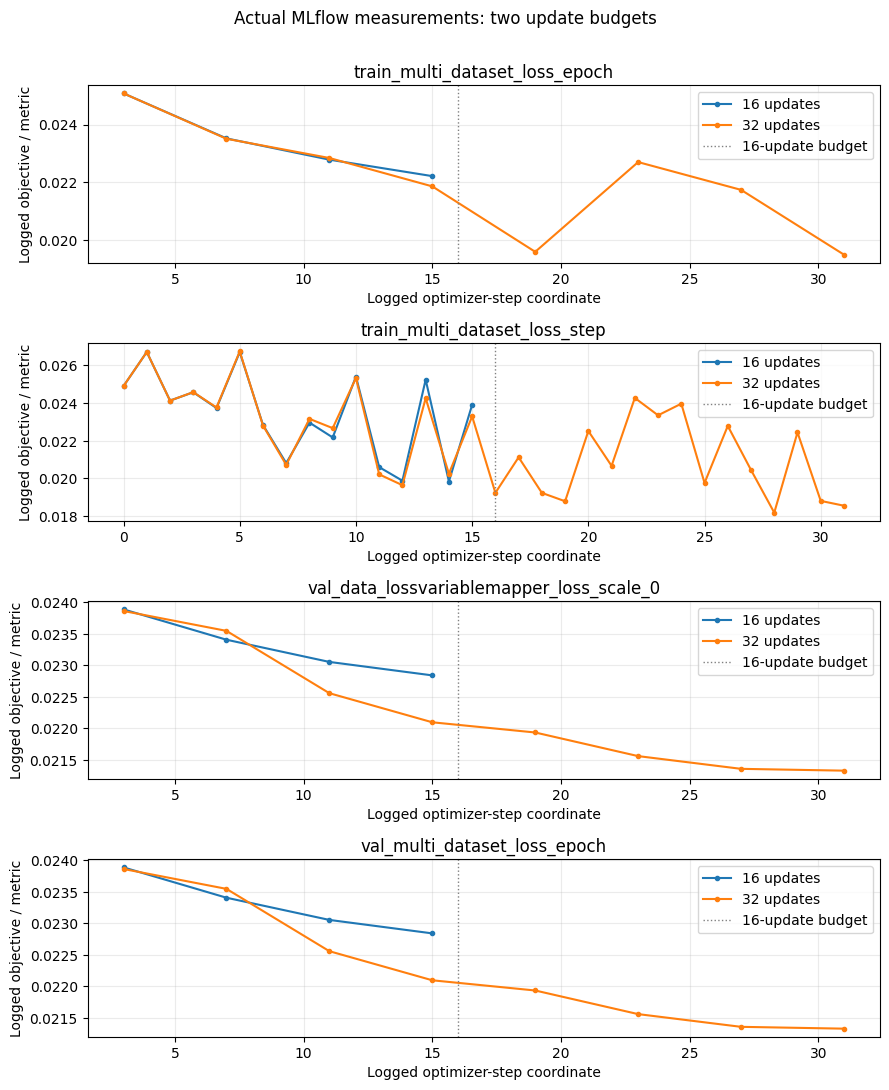

In [16]:
import matplotlib.pyplot as plt
all_metric_names = sorted(history["metric"].unique())
# Keep the figure readable; the preceding table includes every logged loss/MSE.
preferred = [name for name in all_metric_names if "loss" in name.lower()]
preferred += [name for name in all_metric_names if "2t" in name.lower()]
metric_names = list(dict.fromkeys(preferred or all_metric_names))[:4]
print("Plotted metrics:", metric_names)
fig, axes = plt.subplots(len(metric_names), 1, figsize=(9, max(3.2, 2.7 * len(metric_names))), squeeze=False)
for ax, metric_name in zip(axes[:, 0], metric_names):
    for label, frame in histories.items():
        series = frame[frame["metric"] == metric_name].sort_values("step")
        if not series.empty:
            ax.plot(series["step"], series["value"], marker="o", ms=3, label=label)
    ax.axvline(16, color="0.5", ls=":", lw=1, label="16-update budget")
    ax.set(title=metric_name, xlabel="Logged optimizer-step coordinate", ylabel="Logged objective / metric")
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("Actual MLflow measurements: two update budgets", y=1.005)
fig.tight_layout()
fig.savefig(OUTPUT / "training-two-run-metrics.png", dpi=130, bbox_inches="tight")
plt.show()

,trial,metric,step,value
23,16 updates,train_multi_dataset_loss_epoch,15,0.022209
111,32 updates,train_multi_dataset_loss_epoch,31,0.019484
19,16 updates,train_multi_dataset_loss_step,15,0.023905
103,32 updates,train_multi_dataset_loss_step,31,0.018538
31,16 updates,val_data_lossvariablemapper_loss_scale_0,15,0.022840
127,32 updates,val_data_lossvariablemapper_loss_scale_0,31,0.021331
43,16 updates,val_data_mse_metric/data/2t/1_scale_0,15,7.619061
151,32 updates,val_data_mse_metric/data/2t/1_scale_0,31,6.188312
55,16 updates,val_data_mse_metric/data/all/1_scale_0,15,28886.136719
175,32 updates,val_data_mse_metric/data/all/1_scale_0,31,28198.027344


Read learning-rate metrics independently of the loss helper:


,trial,metric,step,value
0,16 updates,lr-AdamW,0,0.000000
1,16 updates,lr-AdamW,1,0.000500
2,16 updates,lr-AdamW,2,0.000962
3,16 updates,lr-AdamW,3,0.000916
4,16 updates,lr-AdamW,4,0.000854
5,16 updates,lr-AdamW,5,0.000778
6,16 updates,lr-AdamW,6,0.000691
7,16 updates,lr-AdamW,7,0.000598
8,16 updates,lr-AdamW,8,0.000500
9,16 updates,lr-AdamW,9,0.000403


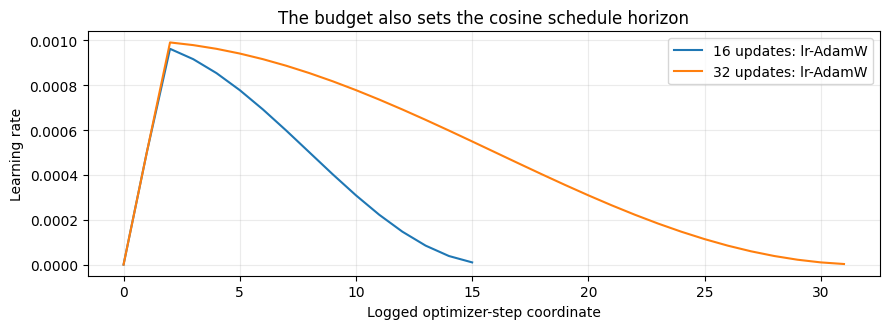

In [17]:
# Preserve metric names: do not merge quantities merely because both contain 'loss'.
last_values = history.sort_values("step").groupby(["trial", "metric"], as_index=False).tail(1)
display(last_values[["trial", "metric", "step", "value"]].sort_values(["metric", "trial"]))
print("Read learning-rate metrics independently of the loss helper:")
lr_rows = []
for label, record in (("16 updates", result), ("32 updates", comparison)):
    client = mlflow.tracking.MlflowClient(tracking_uri=record["tracking_uri"])
    metric_keys = client.get_run(record["run_id"]).data.metrics
    for key in metric_keys:
        if "lr" in key.lower() or "learning_rate" in key.lower():
            for point in client.get_metric_history(record["run_id"], key):
                lr_rows.append({"trial": label, "metric": key, "step": point.step, "value": point.value})
learning_rates = pd.DataFrame(lr_rows)
display(learning_rates if not learning_rates.empty else pd.DataFrame({"note": ["No learning-rate metric was logged; use resolved scheduler settings and trainer source."]}))
if not learning_rates.empty:
    fig, ax = plt.subplots(figsize=(9, 3.4))
    for (label, metric_name), frame in learning_rates.groupby(["trial", "metric"]):
        ordered = frame.sort_values("step")
        ax.plot(ordered["step"], ordered["value"], label=f"{label}: {metric_name}")
    ax.set(xlabel="Logged optimizer-step coordinate", ylabel="Learning rate",
           title="The budget also sets the cosine schedule horizon")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT / "training-two-run-learning-rates.png", dpi=130, bbox_inches="tight")
    plt.show()


**Interpretation exercise**

1. Find one metric logged in both runs. Report its name, last observation step, and both values; explain whether it is a training or validation quantity.
2. Does the longer run improve every plotted quantity? Distinguish what you observe from what one seed can support.
3. If training loss falls while validation loss rises, list two plausible explanations and one follow-up experiment.
4. Identify which claim requires notebook 3: “lower optimization objective” or “better forecasts than persistence at twelve hours”?

**Discussion guide:** optimization can reduce training loss without a reliable out-of-sample gain. Sampling variability, overfitting and schedule changes can all matter.
Repeat seeds and evaluate more independent dates before generalizing. A common held-out inference case is needed to compare checkpoints fairly; physical-unit forecast errors and persistence comparisons belong to notebook 3.

## 7. Audit stopping and checkpoint provenance



The inference checkpoint is selected from this run's saved `inference-*.ckpt` files by modification time. That selection means **latest saved**, not “best validation score”.
An inference artifact carries the trained model and metadata required for rollout; a training checkpoint is also needed when resuming optimizer state.
Read the checkpoint callback settings and trainer stopping messages before making stronger claims about what the selected file represents.

In [18]:
display(config["diagnostics"].get("checkpoint", config["diagnostics"].get("checkpoints", {})))
for label, record in (("16 updates", result), ("32 updates", comparison)):
    log_text = Path(record["log"]).read_text(errors="replace")
    evidence = [
        line for line in log_text.splitlines()
        if any(term in line.lower() for term in ("max_steps", "stopped", "checkpoint", "seed"))
    ]
    print("\n" + label + " — relevant trainer messages")
    print("\n".join(evidence[-12:]))
    checkpoint = Path(record["inference_checkpoint"])
    print("Selected:", checkpoint.name, "| bytes:", checkpoint.stat().st_size)
    print("Resolved-config SHA-256:", hashlib.sha256(Path(record["resolved_config"]).read_bytes()).hexdigest())

{'every_n_minutes': {'save_frequency': None, 'num_models_saved': 3},
 'every_n_epochs': {'save_frequency': 1, 'num_models_saved': 3},
 'every_n_train_steps': {'save_frequency': None, 'num_models_saved': 0}}


16 updates — relevant trainer messages
[2026-09-25 01:35:40,893][anemoi.utils.checkpoints][INFO] - Saving metadata to archive/anemoi-metadata/anemoi.json
[2026-09-25 01:35:40,894][anemoi.utils.checkpoints][INFO] - Saving supporting array `latitudes` to archive/anemoi-metadata/data/latitudes.numpy (shape=(10944,), dtype=float64)
[2026-09-25 01:35:40,894][anemoi.utils.checkpoints][INFO] - Saving supporting array `longitudes` to archive/anemoi-metadata/data/longitudes.numpy (shape=(10944,), dtype=float64)
[2026-09-25 01:35:41,024][anemoi.utils.checkpoints][INFO] - Adding extra information to checkpoint /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/training/20260925-013438-2176cb72-steps16/checkpoint/20719e5b217e4c8fad4055268354fb92/inference-last.ckpt
[2026-09-25 01:35:41,024][anemoi.utils.checkpoints][INFO] - Saving metadata to inference-last/anemoi-metadata/anemoi.json
[2026-09-25 01:35:41,025][anemoi.utils.checkpoints][INFO] - Saving supporting array 

## 8. Explain the result and pass it to inference

**Write a three-sentence result:** name the controlled change; cite one measured result with metric name and step; state one limitation.
Avoid “twice the updates means twice the skill”. An unsuccessful hypothesis is still informative when the configuration and evidence are recorded.

**Answer notes:** with four optimizer updates per epoch, the budgets nominally cover four and eight epochs. Both begin fresh. The four-update preview trained nothing.
A schema-valid recipe can still fail when data or the graph are loaded. The primary manifest remains the 16-update baseline; `comparison` names the independent 32-update trial.
Use the same initialization dates, forecast leads, variables and verification weights when comparing their forecasts in notebook 3.

**Optional extension (after the core sequence):** repeat both budgets with a second seed in fresh directories, or change learning rate while holding the update budget fixed.
State which scheduler quantities are held fixed and report variability instead of selecting a favorable single run.

**Sources:** the local `configs/module-03_04/forecast_6h.yaml` and its Hydra defaults; the installed Anemoi Training 0.12.1 / Models 0.14.1 source; the native command logs and MLflow histories generated here.
Diagrams and exercises are original course material. Package versions are recorded in each run's `environment.json`.

In [19]:
# Reload exactly what the next notebook will consume.
handoff = json.loads(manifest_path.read_text())
for record in (handoff, handoff["comparison"]):
    for key in ("inference_checkpoint", "resolved_config", "graph", "log"):
        assert Path(record[key]).is_file(), f"Missing handoff artifact: {key}"
    assert record["graph_sha256"] == graph_sha256
display(pd.DataFrame([
    {"consumer": "Notebook 3 baseline", "updates": handoff["max_steps"], "checkpoint": handoff["inference_checkpoint"]},
    {"consumer": "Notebook 3 matched comparison", "updates": handoff["comparison"]["max_steps"],
     "checkpoint": handoff["comparison"]["inference_checkpoint"]},
]))

,consumer,updates,checkpoint
0,Notebook 3 baseline,16,/gpfs/scratch/bsc32/bsc437208/module03_04-inte...
1,Notebook 3 matched comparison,32,/gpfs/scratch/bsc32/bsc437208/module03_04-inte...
